<a href="https://colab.research.google.com/github/DaniJonesOcean/etc-impacts-great-lakes/blob/dcj_issue20_map/Figure_4_Origin_Maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cartopy shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 41.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
# Mounting Google Drive in Google Colab
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
myPath = "/content/gdrive/MyDrive/ETC Clustering Paper/cfsr_storms_labeled_k2.csv"
df = pd.read_csv(myPath)
df.head()

,min_p_cent,max_p_grad,max_radius,max_uv,fraction_of_time_in_GLR,maturity_glr0_minus_genesis_ratio,sup_ttl_precip,mi_ttl_precip,huron_ttl_precip,erie_ttl_precip,...,enso_best_value,ipo_value,nao_value,pdo_value,pna_value,pol_value,qbo_value,wp_value,k2_cluster,k2_posterior
0,1007.534375,13.014696,888.486645,132.679247,0.200000,0.533333,0.008939,0.004745,0.006958,0.007487,...,0.224352,0.128273,-2.023275,-0.43032,-1.399966,0.670369,5.300417,1.403931,0,0.999535
1,1004.919297,14.567884,743.147127,127.950766,0.000000,0.266667,0.007820,0.003807,0.005326,0.008860,...,0.224352,0.128273,-2.023275,-0.43032,-1.399966,0.670369,5.300417,1.403931,1,0.991803
2,984.576641,24.076204,1623.945014,107.086910,0.166667,0.125000,0.007253,0.031011,0.027484,0.017373,...,0.224352,0.128273,-2.023275,-0.43032,-1.399966,0.670369,5.300417,1.403931,1,0.999581
3,1008.355938,17.208477,1660.529852,117.163265,0.111111,0.000000,0.010575,0.010530,0.012207,0.008459,...,0.224352,0.128273,-2.023275,-0.43032,-1.399966,0.670369,5.300417,1.403931,1,0.999998
4,1005.740703,12.624121,590.380661,90.981127,0.500000,0.500000,0.007816,0.009645,0.007444,0.016935,...,0.224352,0.128273,-2.023275,-0.43032,-1.399966,0.670369,5.300417,1.403931,0,1.000000


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

# ============================================================
# I/O paths
# ============================================================
CSV_PATH = "/content/gdrive/MyDrive/ETC Clustering Paper/cfsr_storms_labeled_k2.csv"
OUTDIR  = "/content/gdrive/MyDrive/ETC Clustering Paper/figures"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# ============================================================
# Storm type labels
# ============================================================
TYPE1 = "Type 1 (earlier entry)"
TYPE2 = "Type 2 (later entry)"
CLUSTER_TO_TYPE = {
    0: TYPE2,   # adjust if needed
    1: TYPE1,
}

if "storm_type" not in df.columns:
    df["storm_type"] = df["k2_cluster"].map(CLUSTER_TO_TYPE)

# ============================================================
# Figure settings
# ============================================================
lon_min, lon_max = -130, -66
lat_min, lat_max = 24, 65

GLR_BOX = (-92.0, 41.0, 17.0, 8.5)

SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]
TYPE_ORDER = [TYPE1, TYPE2]

TYPE_SHORT = {
    TYPE1: "type1_earlier",
    TYPE2: "type2_later",
}

SEASON_LONG = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Fall",
}

# ============================================================
# Plot helpers
# ============================================================
def setup_ax(ax):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, alpha=0.25)
    ax.add_feature(cfeature.OCEAN, alpha=0.15)
    ax.add_feature(cfeature.LAKES, alpha=0.55)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(
        draw_labels=True, dms=True, x_inline=False, y_inline=False,
        color="k", alpha=0.25, linestyle="--", linewidth=0.5
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

def smooth2d(H, iters=2):
    K = np.array([[1, 2, 1],
                  [2, 4, 2],
                  [1, 2, 1]], dtype=float)
    K /= K.sum()

    A = H.astype(float)
    for _ in range(iters):
        P = np.pad(A, 1, mode="edge")
        A = (
            K[0,0]*P[:-2,:-2] + K[0,1]*P[:-2,1:-1] + K[0,2]*P[:-2,2:] +
            K[1,0]*P[1:-1,:-2] + K[1,1]*P[1:-1,1:-1] + K[1,2]*P[1:-1,2:] +
            K[2,0]*P[2:,:-2] + K[2,1]*P[2:,1:-1] + K[2,2]*P[2:,2:]
        )
    return A

# ============================================================
# Core function: 2x2 figure
# ============================================================

def plot_genesis_density_2x2_son_jja(
    df,
    seasons=("SON", "JJA"),
    storm_types=(TYPE1, TYPE2),
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    outdir=OUTDIR,
    fname="genesis_density_2x2_son_jja.png",
    scaling="panel",
):
    required = {"lon_gen", "lat_gen", "storm_type", "season"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in CSV: {sorted(missing)}")

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(14, 10),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=False,
    )

    panel_data = {}

    # ---- First pass: compute raw grids ----
    for r, season in enumerate(seasons):
        for c, storm_type in enumerate(storm_types):
            d = df[
                (df["storm_type"] == storm_type) &
                (df["season"] == season)
            ].dropna(subset=["lon_gen", "lat_gen"]).copy()

            lon_bins = np.arange(lon_min, lon_max + dlon, dlon)
            lat_bins = np.arange(lat_min, lat_max + dlat, dlat)

            H, xedges, yedges = np.histogram2d(
                d["lon_gen"],
                d["lat_gen"],
                bins=[lon_bins, lat_bins],
            )

            H = H.T

            if smooth_iters > 0:
                H = smooth2d(H, iters=smooth_iters)

            panel_data[(r, c)] = {
                "H": H,
                "xedges": xedges,
                "yedges": yedges,
                "n": len(d),
                "season": season,
                "storm_type": storm_type,
            }

    # ---- Scaling choice ----
    if scaling == "global":
        all_max = max(item["H"].max() for item in panel_data.values())
        all_max = all_max if all_max > 0 else 1.0

        for item in panel_data.values():
            Hnorm = item["H"] / all_max
            if np.any(Hnorm > 0):
                upper = np.quantile(Hnorm[Hnorm > 0], clip_q)
                item["Hplot"] = np.clip(Hnorm, 0, upper)
                item["panel_clip"] = upper
            else:
                item["Hplot"] = Hnorm
                item["panel_clip"] = 1.0
        cbar_label = f"Relative genesis density (common scale, clipped @ {int(clip_q*100)}th percentile)"

    elif scaling == "panel":
        for item in panel_data.values():
            hmax = item["H"].max()
            Hnorm = item["H"] / hmax if hmax > 0 else item["H"]
            if np.any(Hnorm > 0):
                upper = np.quantile(Hnorm[Hnorm > 0], clip_q)
                item["Hplot"] = np.clip(Hnorm, 0, upper)
                item["panel_clip"] = upper
            else:
                item["Hplot"] = Hnorm
                item["panel_clip"] = 1.0
        cbar_label = f"Relative genesis density (panel-normalized, clipped @ {int(clip_q*100)}th percentile)"
    else:
        raise ValueError("scaling must be 'panel' or 'global'")

    # ---- Plot panels ----
    mappable = None
    for r in range(2):
        for c in range(2):
            ax = axes[r, c]
            setup_ax(ax)

            item = panel_data[(r, c)]
            Hplot = item["Hplot"]
            xedges = item["xedges"]
            yedges = item["yedges"]
            n = item["n"]
            season = item["season"]
            storm_type = item["storm_type"]

            X, Y = np.meshgrid(xedges, yedges)

            pm = ax.pcolormesh(
                X, Y, Hplot,
                transform=ccrs.PlateCarree(),
                shading="auto",
                alpha=1.0,
                cmap="Purples",
                vmin=0,
                vmax=item["panel_clip"] if scaling == "panel" else 1,
            )
            mappable = pm

            rect = Rectangle(
                (GLR_BOX[0], GLR_BOX[1]),
                GLR_BOX[2], GLR_BOX[3],
                fill=False, linewidth=2.0, edgecolor="k",
                transform=ccrs.PlateCarree(),
            )
            ax.add_patch(rect)

            ax.text(
                GLR_BOX[0] + 0.7,
                GLR_BOX[1] + GLR_BOX[3] - 0.8,
                "GLR",
                fontsize=11,
                weight="bold",
                transform=ccrs.PlateCarree(),
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2.0)
            )

            season_name = SEASON_LONG.get(season, season)
            ax.set_title(f"{storm_type}, {season_name} (n={n})", fontsize=12)

    # ---- Panel labels (outside) ----
    panel_labels = ["(a)", "(b)", "(c)", "(d)"]
    for ax, label in zip(axes.flatten(), panel_labels):
        ax.text(
            -0.08, 1.05, label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False,
        )

    # ---- Colorbar ----
    fig.subplots_adjust(right=0.88, wspace=0.12, hspace=0.18)
    cax = fig.add_axes([0.90, 0.20, 0.02, 0.60])
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(cbar_label)

    outpath = os.path.join(outdir, fname)
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return outpath

# ============================================================
# Core function: one (storm type, season) figure
# ============================================================
def plot_genesis_density_single(
    df,
    storm_type,
    season,
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    normalize=True,
    outdir=OUTDIR,
    fname=None,
):
    required = {"lon_gen", "lat_gen", "storm_type", "season"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in CSV: {sorted(missing)}")

    d = df[(df["storm_type"] == storm_type) & (df["season"] == season)].dropna(
        subset=["lon_gen", "lat_gen"]
    ).copy()

    if d.empty:
        print(f"No storms found for {storm_type}, {season}")
        return None

    fig = plt.figure(figsize=(12, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    setup_ax(ax)

    # Explicit spatial grid in degrees
    lon_bins = np.arange(lon_min, lon_max + dlon, dlon)
    lat_bins = np.arange(lat_min, lat_max + dlat, dlat)

    H, xedges, yedges = np.histogram2d(
        d["lon_gen"],
        d["lat_gen"],
        bins=[lon_bins, lat_bins],
    )

    H = H.T

    if normalize and H.sum() > 0:
        H = H / H.sum()

    Hs = smooth2d(H, iters=smooth_iters)

    if np.any(Hs > 0):
        upper = np.quantile(Hs[Hs > 0], clip_q)
        Hplot = np.clip(Hs, 0, upper)
    else:
        Hplot = Hs

    X, Y = np.meshgrid(xedges, yedges)

    pm = ax.pcolormesh(
        X, Y, Hplot,
        transform=ccrs.PlateCarree(),
        shading="auto",
        alpha=1.0,
        cmap="Purples",
        vmin=0,
    )

    cbar = fig.colorbar(pm, ax=ax, shrink=0.85, pad=0.02)
    if normalize:
        cbar.set_label(f"Genesis density (fraction per {dlon:.1f}° × {dlat:.1f}° grid cell)")
    else:
        cbar.set_label(f"Genesis count per {dlon:.1f}° × {dlat:.1f}° grid cell")

    rect = Rectangle(
        (GLR_BOX[0], GLR_BOX[1]),
        GLR_BOX[2], GLR_BOX[3],
        fill=False, linewidth=2.5, edgecolor="k",
        transform=ccrs.PlateCarree(),
    )
    ax.add_patch(rect)

    ax.text(
        GLR_BOX[0] + 0.7,
        GLR_BOX[1] + GLR_BOX[3] - 0.8,
        "GLR",
        fontsize=12,
        weight="bold",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2.5)
    )

    season_name = SEASON_LONG.get(season, season)
    ax.set_title(f"{storm_type}, {season_name} (n={len(d)})", fontsize=14)
    fig.tight_layout()

    if fname is None:
        fname = f"genesis_density_{TYPE_SHORT[storm_type]}_{season.lower()}.png"

    outpath = os.path.join(outdir, fname)
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return outpath

# ============================================================
# Batch function: all separate figures
# ============================================================
def save_all_stormtype_season_figures(
    df,
    seasons=SEASON_ORDER,
    storm_types=TYPE_ORDER,
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    normalize=True,
    outdir=OUTDIR,
):
    saved = []

    for season in seasons:
        for storm_type in storm_types:
            outpath = plot_genesis_density_single(
                df=df,
                storm_type=storm_type,
                season=season,
                dlon=dlon,
                dlat=dlat,
                smooth_iters=smooth_iters,
                clip_q=clip_q,
                normalize=normalize,
                outdir=outdir,
            )
            if outpath is not None:
                saved.append(outpath)
                print("Saved:", outpath)

    return saved



/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://nat

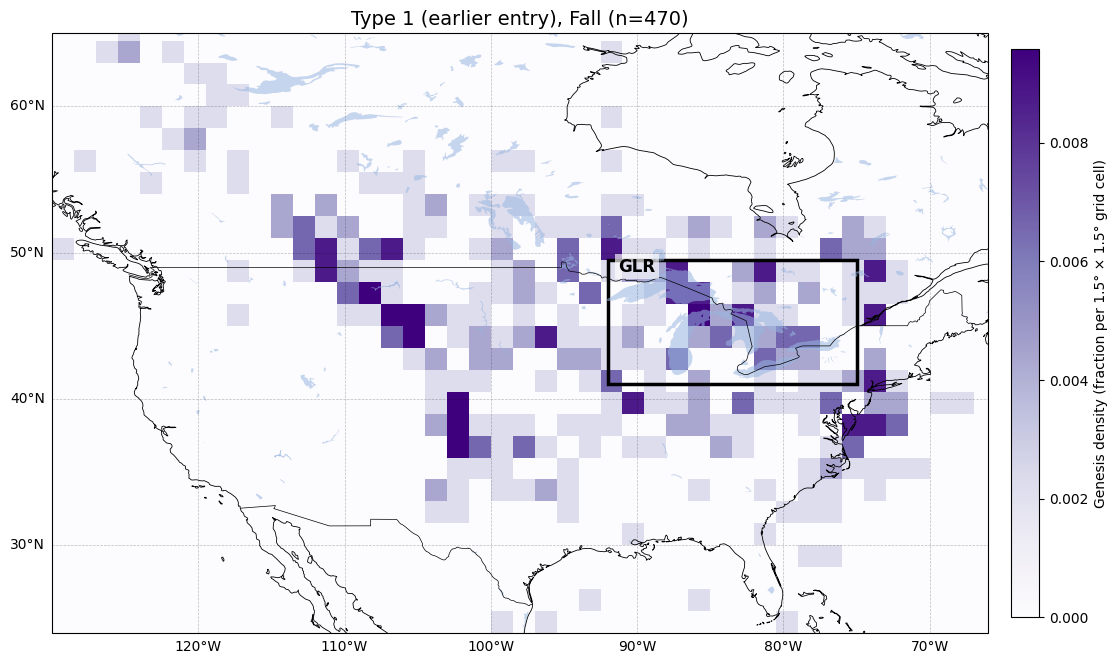

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type1_earlier_son.png


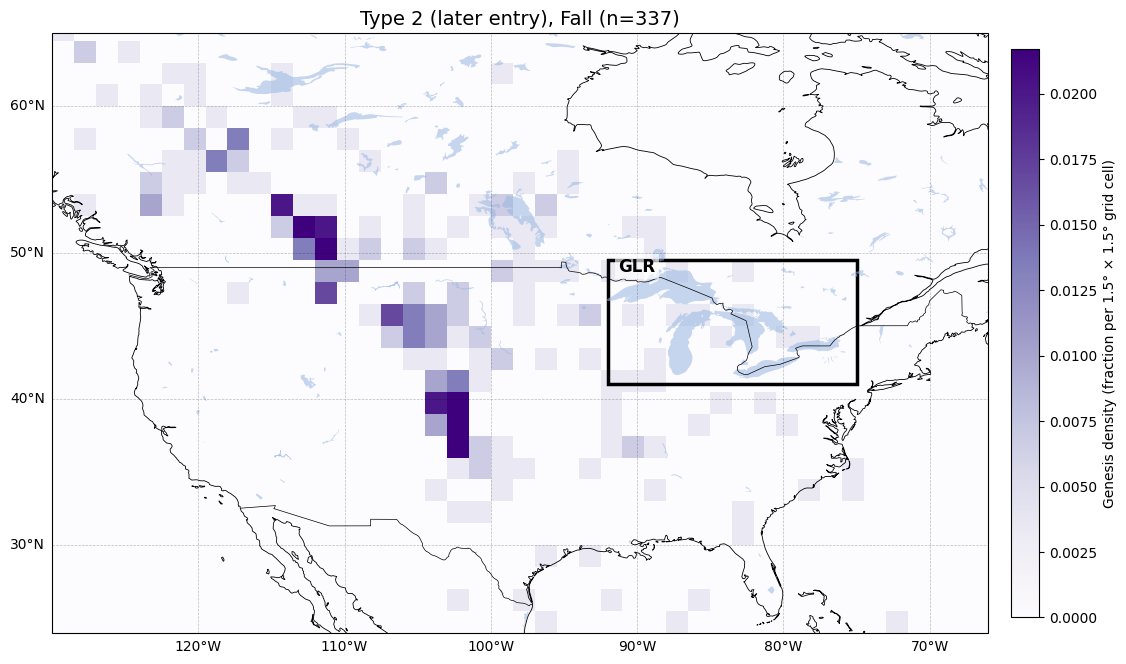

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type2_later_son.png


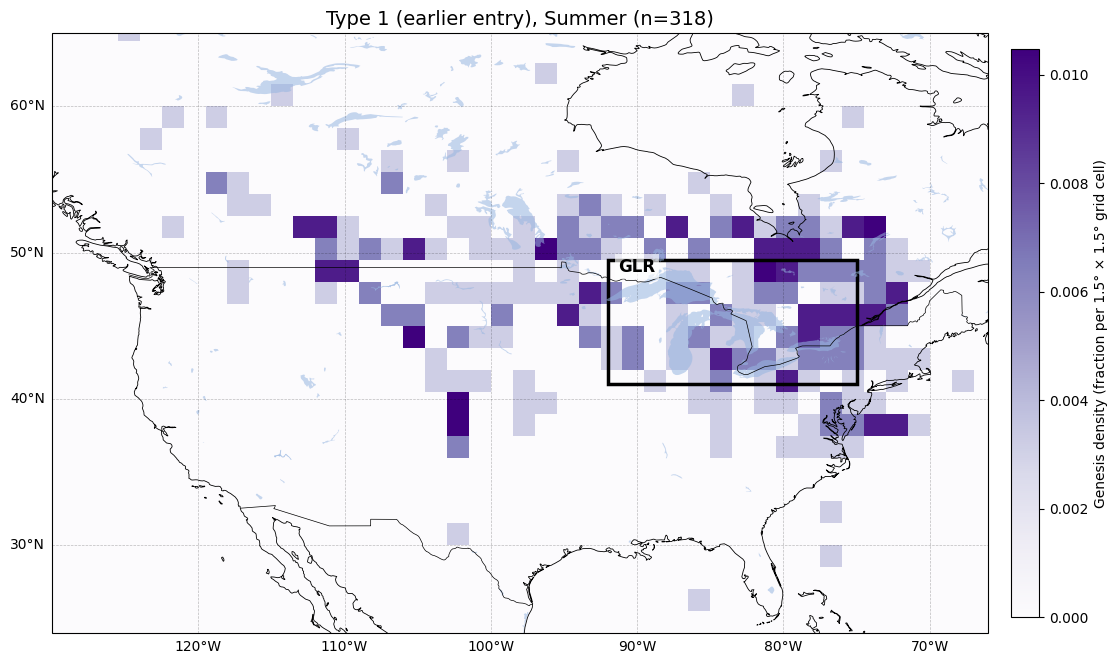

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type1_earlier_jja.png


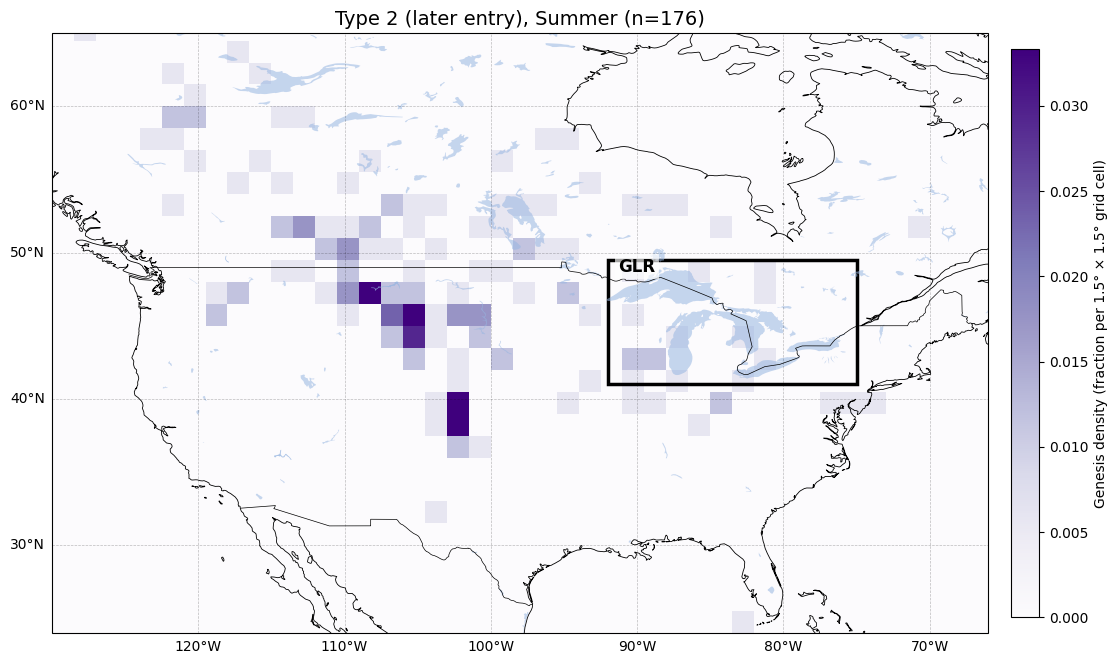

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type2_later_jja.png


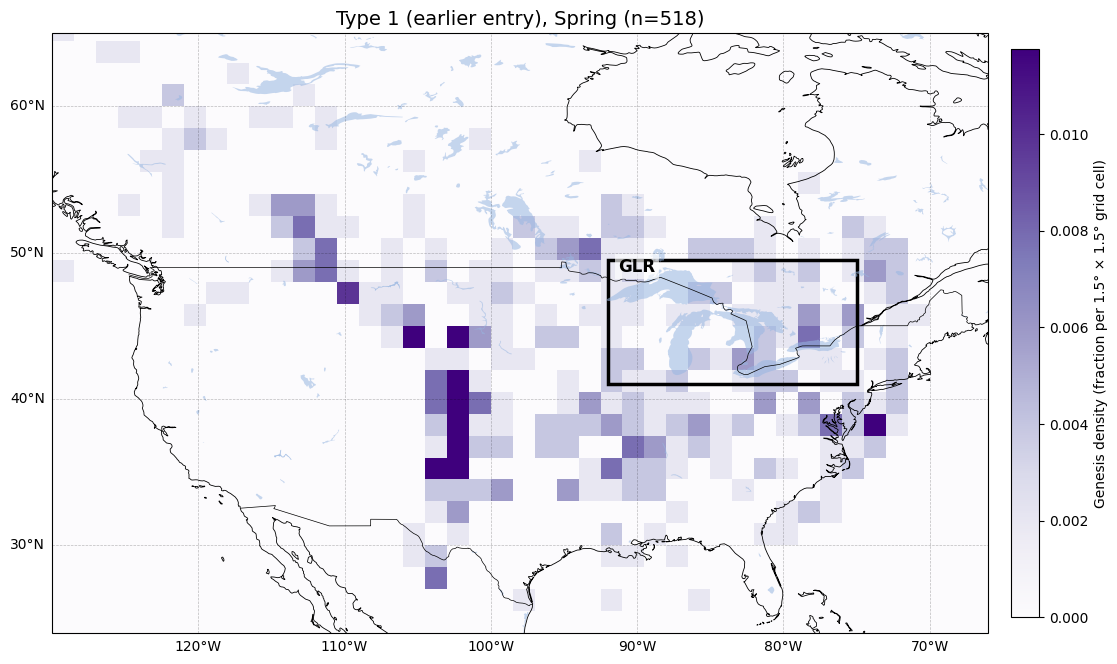

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type1_earlier_mam.png


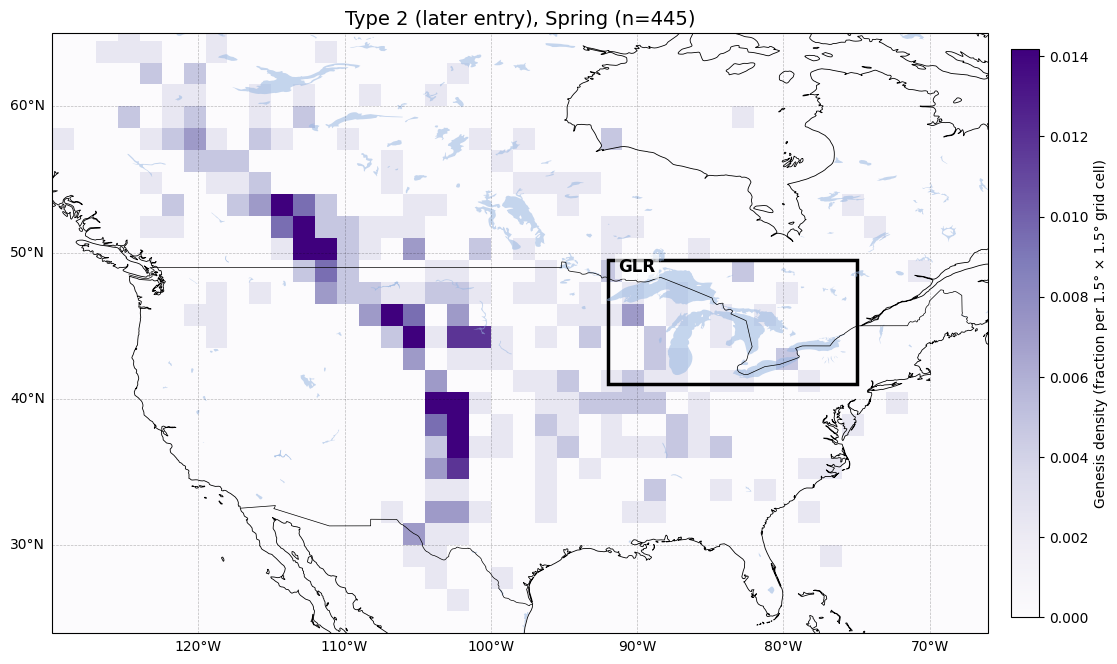

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type2_later_mam.png


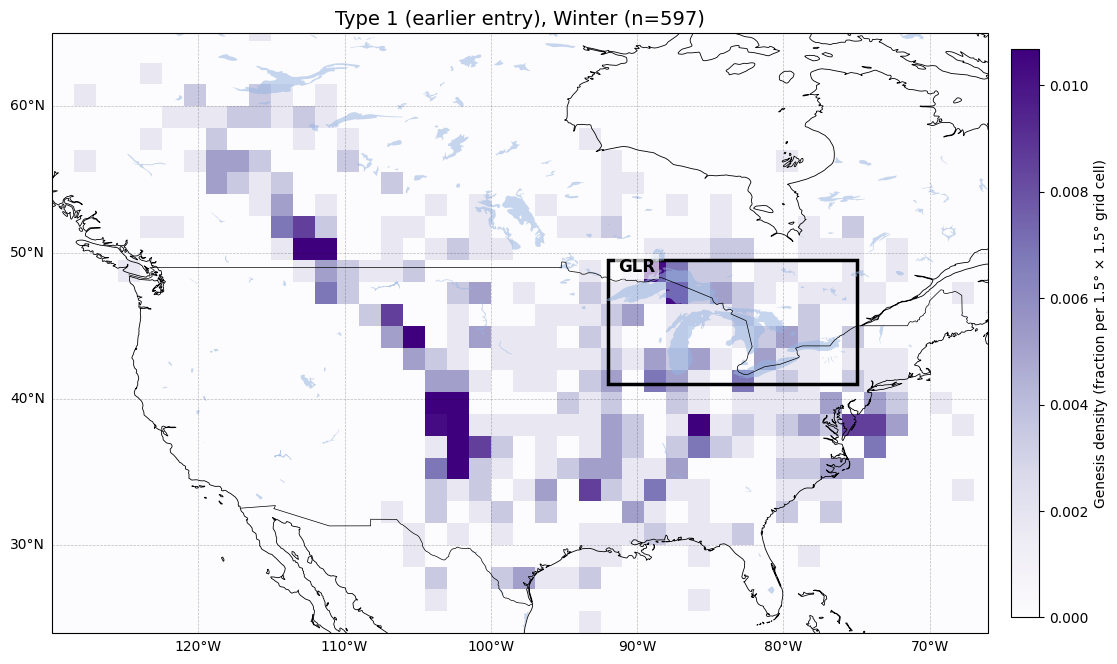

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type1_earlier_djf.png


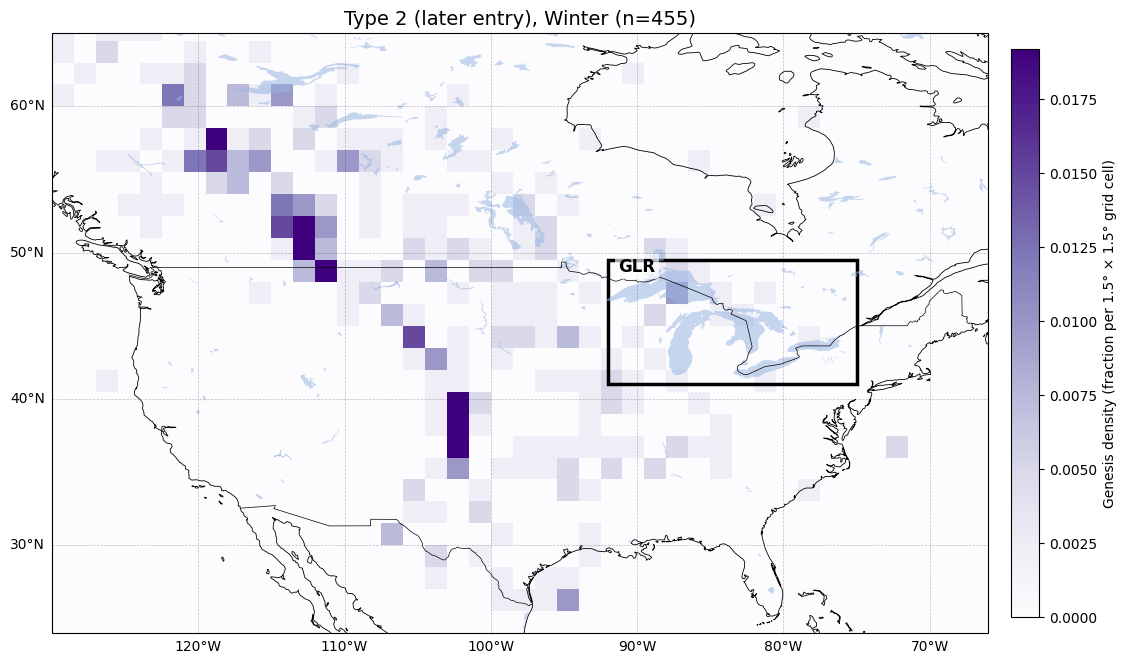

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_type2_later_djf.png


In [6]:
# ============================================================
# Run: save one figure per (storm type, season)
# ============================================================
saved_files = save_all_stormtype_season_figures(
    df,
    seasons=["SON", "JJA", "MAM", "DJF"],   # change order if you want
    storm_types=[TYPE1, TYPE2],
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    normalize=True,
    outdir=OUTDIR,
)



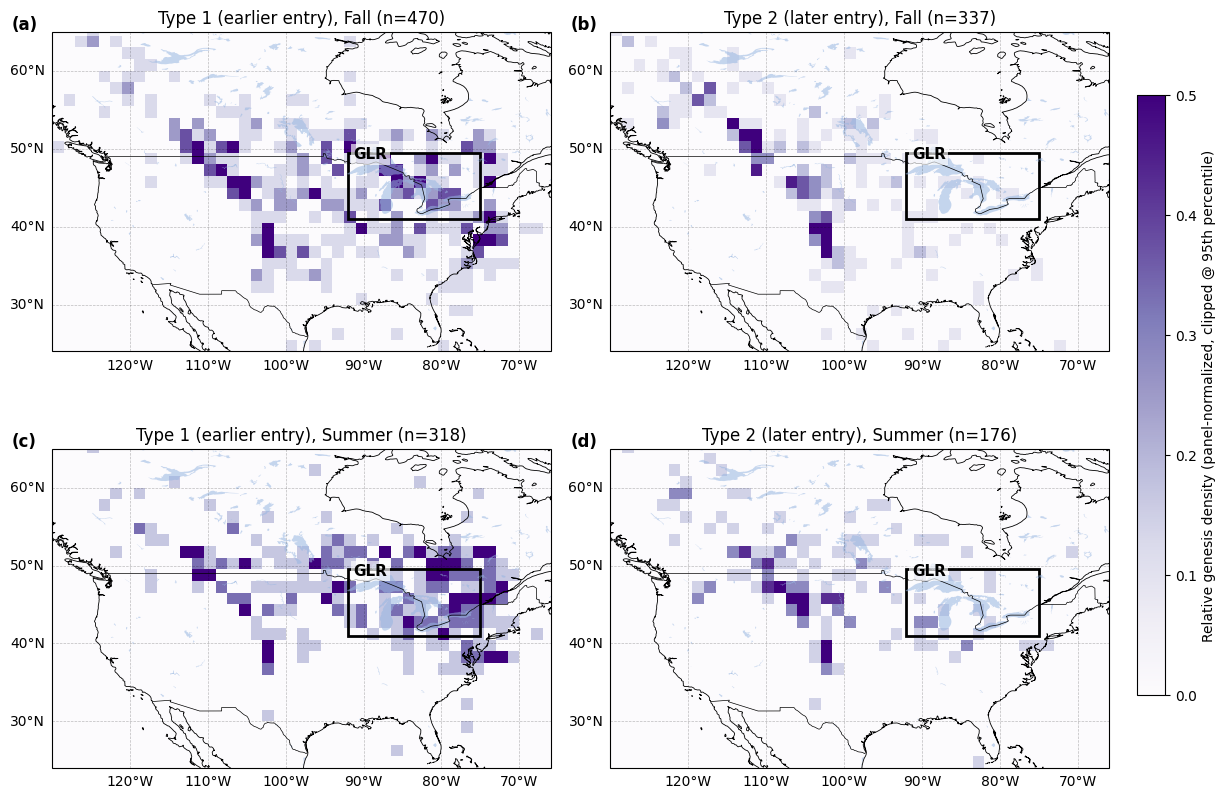

Saved: /content/gdrive/MyDrive/ETC Clustering Paper/figures/genesis_density_2x2_son_jja_panelnorm.png


In [7]:
outpath = plot_genesis_density_2x2_son_jja(
    df=df,
    seasons=("SON", "JJA"),
    storm_types=(TYPE1, TYPE2),
    dlon=1.5,
    dlat=1.5,
    clip_q=0.95,
    smooth_iters=0,
    scaling="panel",
    outdir=OUTDIR,
    fname="genesis_density_2x2_son_jja_panelnorm.png",
)
print("Saved:", outpath)